# 05 - Significance, Interpretability, Efficiency

**Phase 5.** The final experimental phase. Three questions, then the results are frozen.

1. **Significance** (objective 6): are the differences between the top models real, or could
   they be luck on one particular test set?
2. **Interpretability** (objective 7): *why* do the models decide what they decide? Restricted
   to the best linear model and XGBoost, as the approved scope requires.
3. **Efficiency** (objective 8): what does each model cost in training time, prediction latency
   and stored size?

After this notebook runs, `results/` is final. Any later change that would move a number gets
flagged rather than made silently.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # precede numpy/xgboost import: avoids OpenMP deadlock

import sys, json, ast, pickle
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from statsmodels.stats.contingency_tables import mcnemar

from src import config
from src.preprocessing import load_dataset, make_split
from src.features import bow, tfidf_unigram, tfidf_ngram, lexical_pipeline, hybrid, StatisticalFeatures
from src.models import get_models
from src.evaluation import metrics, get_scores, time_and_size

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
np.random.seed(config.RANDOM_SEED)
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Rebuild the frozen configurations

Same guards as every other notebook: the row count must match what notebook 01 persisted, and
the split is reloaded rather than regenerated. Each model is rebuilt at its Phase-2 winning
representation with its Phase-2 winning hyperparameters, both read from
`results/master_metrics.csv` rather than typed in, so this notebook cannot drift from the
earlier ones.

In [2]:
df = load_dataset()
eda = pd.read_csv(RESULTS / "eda_summary.csv").iloc[0]
assert len(df) == int(eda["rows_dedup"]), f"row count changed: {len(df)} != {int(eda['rows_dedup'])}"

X_train, X_test, y_train, y_test = make_split(df)
assert config.SPLIT_PATH.exists(), "the persisted split is missing - do not re-split here"
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

mm = pd.read_csv(RESULTS / "master_metrics.csv")
best_rep = mm.loc[mm.groupby("model")["f1"].idxmax()].set_index("model")

MIN_DF = 2
VECTORIZERS = {
    "bow":           lambda: bow(min_df=MIN_DF),
    "tfidf_unigram": lambda: tfidf_unigram(min_df=MIN_DF),
    "tfidf_bigram":  lambda: tfidf_ngram(max_n=2, min_df=MIN_DF),
    "tfidf_trigram": lambda: tfidf_ngram(max_n=3, min_df=MIN_DF),
}
models_all = get_models(scale_pos_weight=scale_pos_weight)
MODEL_ORDER = ["MultinomialNB", "LogisticRegression", "LinearSVM", "XGBoost"]


def build(model_name, feature_set="text_only"):
    '''Rebuild one frozen configuration: its Phase-2 representation and best params.'''
    rep = best_rep.loc[model_name, "representation"]
    # best_params was written to CSV as a Python dict literal by notebook 02.
    # literal_eval, not eval: it parses literals only and cannot execute code.
    params = ast.literal_eval(best_rep.loc[model_name, "best_params"])
    est = clone(models_all[model_name][0]).set_params(**params)
    make = hybrid if feature_set == "hybrid" else lexical_pipeline
    from sklearn.pipeline import Pipeline
    return Pipeline([("vec", make(VECTORIZERS[rep]())), ("clf", est)]), rep, params


for name in MODEL_ORDER:
    _, rep, params = build(name)
    print(f"  {name:20s} {rep:14s} {params}")
print(f"\ntrain={len(X_train)}  test={len(X_test)}  scale_pos_weight={scale_pos_weight:.3f}")

  MultinomialNB        bow            {'alpha': 1.0}
  LogisticRegression   tfidf_bigram   {'C': 10}
  LinearSVM            tfidf_unigram  {'C': 1}
  XGBoost              bow            {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 200}

train=4126  test=1032  scale_pos_weight=7.027


## 2. Significance testing (objective 6)

Two tests that answer two different questions and take two different inputs. They are easy to
confuse, so the distinction is stated explicitly:

- **McNemar's test** is **paired on the same test set**. Its input is the two models'
  prediction arrays over the identical 1,032 test messages. It looks only at the messages the
  two models *disagree* about: if model A is right on 12 that B gets wrong, and B is right on 4
  that A gets wrong, is 12-vs-4 more lopsided than a coin flip would produce? It answers "do
  these two classifiers behave differently on this test set?"
- **The paired t-test** is **across cross-validation folds**. Its input is five per-fold F1
  scores per model, from the identical stratified folds. It answers "is the F1 gap stable, or
  does it flip around depending on which slice of the training data you look at?"

Both are needed because either alone is weak: McNemar sees one test set, and the t-test never
touches the held-out data.

Two pairs are tested, not one. The top-2 against each other answers "which model should be
recommended". The best linear model against XGBoost tests the study's **headline claim** - that
linear models beat gradient-boosted trees on sparse short text. If only the first pair were
tested and it returned a null result, the main finding of the study would go unexamined.

In [3]:
top = json.load(open(RESULTS / "top_models.json"))
A_NAME, B_NAME = top[0]["model"], top[1]["model"]

# Two comparisons, because they answer two different questions:
#   1. the top-2 against each other  -> "which model should be recommended?"
#   2. the best linear model against XGBoost -> tests the study's headline claim that
#      linear models beat the gradient-boosted trees on this data. Without this pair, a
#      null result on pair 1 alone would leave the main finding untested.
PAIRS = [(A_NAME, B_NAME), (A_NAME, "XGBoost")]

fitted, preds = {}, {}
for name in MODEL_ORDER:
    pipe, _, _ = build(name)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    preds[name] = pipe.predict(X_test)
    acc = (preds[name] == y_test).mean()
    print(f"  {name:20s} test accuracy {acc:.4f}  ({int((preds[name] != y_test).sum())} errors of {len(y_test)})")

mcnemar_results = {}
for a, b in PAIRS:
    a_ok, b_ok = (preds[a] == y_test), (preds[b] == y_test)
    table = np.array([
        [int((a_ok & b_ok).sum()),  int((a_ok & ~b_ok).sum())],
        [int((~a_ok & b_ok).sum()), int((~a_ok & ~b_ok).sum())],
    ])
    n_disc = int(table[0, 1] + table[1, 0])
    # exact=True with few discordant pairs; the chi-square approximation is unreliable
    # below roughly 25 of them, which is exactly the regime these models are in.
    mc = mcnemar(table, exact=(n_disc < 25), correction=True)
    mcnemar_results[(a, b)] = (table, n_disc, mc)

    print(f"\n--- McNemar: {a} vs {b} ---")
    print(pd.DataFrame(table, index=[f"{a} correct", f"{a} wrong"],
                       columns=[f"{b} correct", f"{b} wrong"]))
    print(f"Discordant pairs: {n_disc}  ({table[0,1]} only {a} correct, {table[1,0]} only {b} correct)")
    print(f"statistic={float(mc.statistic):.4f}  p={float(mc.pvalue):.4f}")

  MultinomialNB        test accuracy 0.9835  (17 errors of 1032)


  LogisticRegression   test accuracy 0.9864  (14 errors of 1032)
  LinearSVM            test accuracy 0.9874  (13 errors of 1032)


  XGBoost              test accuracy 0.9826  (18 errors of 1032)

--- McNemar: LinearSVM vs LogisticRegression ---
                   LogisticRegression correct  LogisticRegression wrong
LinearSVM correct                        1017                         2
LinearSVM wrong                             1                        12
Discordant pairs: 3  (2 only LinearSVM correct, 1 only LogisticRegression correct)
statistic=1.0000  p=1.0000

--- McNemar: LinearSVM vs XGBoost ---
                   XGBoost correct  XGBoost wrong
LinearSVM correct             1010              9
LinearSVM wrong                  4              9
Discordant pairs: 13  (9 only LinearSVM correct, 4 only XGBoost correct)
statistic=4.0000  p=0.2668


In [4]:
cv = config.get_cv(5)
fold_f1 = {}
for name in sorted({n for pair in PAIRS for n in pair}):
    pipe, _, _ = build(name)
    fold_f1[name] = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
    print(f"{name:20s} per-fold F1: {np.round(fold_f1[name], 4)}  mean={fold_f1[name].mean():.4f}")

ttest_results = {}
for a, b in PAIRS:
    t_stat, t_p = ttest_rel(fold_f1[a], fold_f1[b])
    ttest_results[(a, b)] = (float(t_stat), float(t_p))
    gap = fold_f1[a].mean() - fold_f1[b].mean()
    print(f"\n{a} vs {b}: mean F1 gap={gap:+.4f}  t={t_stat:.4f}  p={t_p:.4f}")

LinearSVM            per-fold F1: [0.9268 0.9246 0.9184 0.9208 0.8955]  mean=0.9172


LogisticRegression   per-fold F1: [0.9275 0.9208 0.9146 0.9171 0.92  ]  mean=0.9200


XGBoost              per-fold F1: [0.8856 0.9072 0.8955 0.9128 0.8599]  mean=0.8922

LinearSVM vs LogisticRegression: mean F1 gap=-0.0028  t=-0.5036  p=0.6410

LinearSVM vs XGBoost: mean F1 gap=+0.0250  t=4.1432  p=0.0143


In [5]:
ALPHA = 0.05

def verdict(p, what):
    return (f"significant at alpha={ALPHA}: {what}" if p < ALPHA
            else f"NOT significant at alpha={ALPHA}: no evidence that {what}")

rows = []
for a, b in PAIRS:
    table, n_disc, mc = mcnemar_results[(a, b)]
    t_stat, t_p = ttest_results[(a, b)]
    rows.append({
        "test": "McNemar (paired, same test set)", "model_a": a, "model_b": b,
        "input": f"test-set predictions over {len(y_test)} messages",
        "statistic": float(mc.statistic), "p_value": float(mc.pvalue),
        "n_discordant": n_disc,
        "a_only_correct": int(table[0, 1]), "b_only_correct": int(table[1, 0]),
        "significant": bool(mc.pvalue < ALPHA),
        "verdict": verdict(mc.pvalue, f"{a} and {b} make different errors on this test set"),
    })
    rows.append({
        "test": "Paired t-test (across 5 CV folds)", "model_a": a, "model_b": b,
        "input": "per-fold CV F1 on the training set",
        "statistic": t_stat, "p_value": t_p,
        "n_discordant": np.nan, "a_only_correct": np.nan, "b_only_correct": np.nan,
        "significant": bool(t_p < ALPHA),
        "verdict": verdict(t_p, f"the F1 gap between {a} and {b} is consistent across folds"),
    })

sig = pd.DataFrame(rows)
sig.to_csv(RESULTS / "significance.csv", index=False)
print("Saved results/significance.csv\n")
for _, r in sig.iterrows():
    print(f"{r['test']}  |  {r['model_a']} vs {r['model_b']}")
    print(f"  p={r['p_value']:.4f} -> {r['verdict']}\n")
sig[["test", "model_a", "model_b", "statistic", "p_value", "significant"]].round(4)

Saved results/significance.csv

McNemar (paired, same test set)  |  LinearSVM vs LogisticRegression
  p=1.0000 -> NOT significant at alpha=0.05: no evidence that LinearSVM and LogisticRegression make different errors on this test set

Paired t-test (across 5 CV folds)  |  LinearSVM vs LogisticRegression
  p=0.6410 -> NOT significant at alpha=0.05: no evidence that the F1 gap between LinearSVM and LogisticRegression is consistent across folds

McNemar (paired, same test set)  |  LinearSVM vs XGBoost
  p=0.2668 -> NOT significant at alpha=0.05: no evidence that LinearSVM and XGBoost make different errors on this test set

Paired t-test (across 5 CV folds)  |  LinearSVM vs XGBoost
  p=0.0143 -> significant at alpha=0.05: the F1 gap between LinearSVM and XGBoost is consistent across folds



,test,model_a,model_b,statistic,p_value,significant
0,"McNemar (paired, same test set)",LinearSVM,LogisticRegression,1.0000,1.0000,False
1,Paired t-test (across 5 CV folds),LinearSVM,LogisticRegression,-0.5036,0.6410,False
2,"McNemar (paired, same test set)",LinearSVM,XGBoost,4.0000,0.2668,False
3,Paired t-test (across 5 CV folds),LinearSVM,XGBoost,4.1432,0.0143,True


## 3. Interpretability (objective 7)

The approved scope limits this to **the best linear model and XGBoost**. "Best linear model"
needs a stated rule, because two configurations now tie closely on F1. The rule used here:
**the champion recorded in `results/top_models.json`**, which is the Phase-2 winner by F1 and has the
lowest false positive rate among the four models' best configurations (it is not the
lowest-FPR configuration outright; five reach 0.0033). Using it keeps the
interpretability analysis consistent with Phases 2 and 3.

Because Phase 4 showed the statistical features carrying a real lift, a short supplementary
panel also reports what weight the best hybrid model puts on those five features. That is a
direct explanation of the Phase-4 result rather than an extra model.

Interpreting LinearSVM on tfidf_unigram: 3183 features


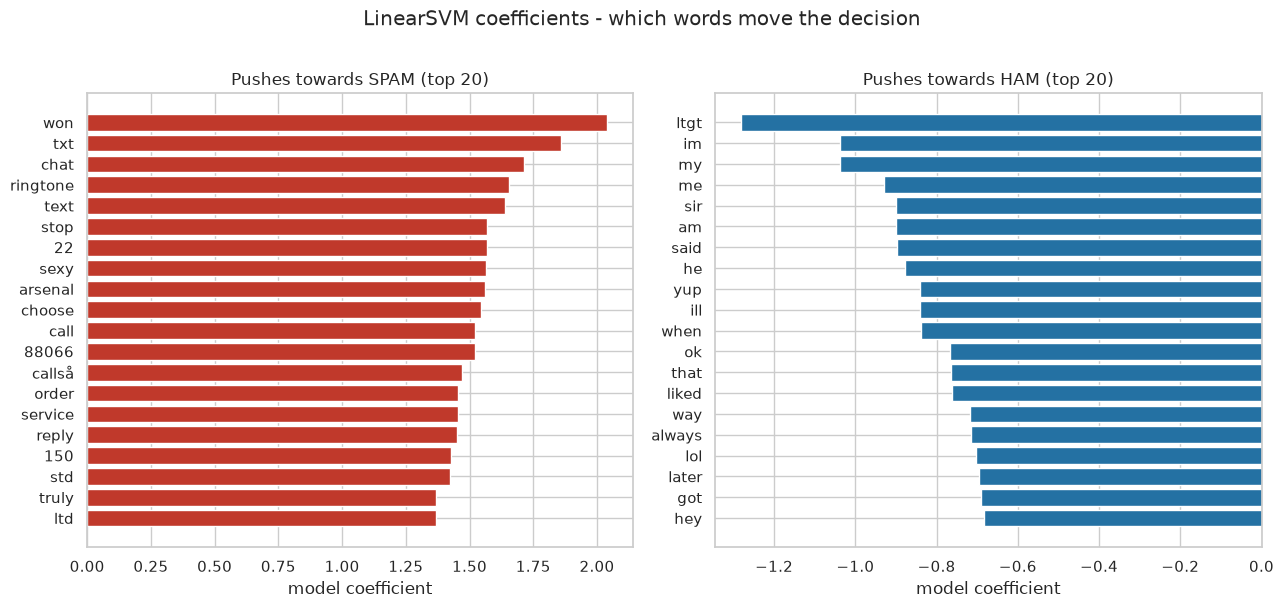

,spam_token,spam_coef,ham_token,ham_coef
0,won,2.0402,ltgt,-1.2805
1,txt,1.8573,im,-1.0370
2,chat,1.7138,my,-1.0367
3,ringtone,1.6545,me,-0.9299
4,text,1.6406,sir,-0.9011
5,stop,1.5680,am,-0.8994
6,22,1.5665,said,-0.8972
7,sexy,1.5642,he,-0.8789
8,arsenal,1.5613,yup,-0.8413
9,choose,1.5439,ill,-0.8406


In [6]:
LINEAR_NAME = A_NAME     # from top_models.json - the study champion by F1, and lowest FPR
lin_pipe = fitted[LINEAR_NAME]
vec = lin_pipe.named_steps["vec"].named_steps["vec"]
clf = lin_pipe.named_steps["clf"]
feature_names = np.asarray(vec.get_feature_names_out())
coefs = np.ravel(clf.coef_)
print(f"Interpreting {LINEAR_NAME} on {best_rep.loc[LINEAR_NAME,'representation']}: "
      f"{len(feature_names)} features")

TOP_N = 20
order = np.argsort(coefs)
most_ham, most_spam = order[:TOP_N], order[-TOP_N:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, idx, title, colour in [
    (axes[0], most_spam, f"Pushes towards SPAM (top {TOP_N})", "#c0392b"),
    (axes[1], most_ham,  f"Pushes towards HAM (top {TOP_N})",  "#2471a3"),
]:
    ax.barh(range(len(idx)), coefs[idx], color=colour)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels(feature_names[idx])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("model coefficient")
fig.suptitle(f"{LINEAR_NAME} coefficients - which words move the decision", y=1.01)
fig.tight_layout()
fig.savefig(RESULTS / "fig_linear_coeffs.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "spam_token": feature_names[most_spam], "spam_coef": coefs[most_spam].round(4),
    "ham_token": feature_names[most_ham], "ham_coef": coefs[most_ham].round(4),
}).head(10)

In [7]:
# Supplementary: what weight does the best hybrid model give the five statistics?
hyb_pipe, hyb_rep, _ = build("LogisticRegression", feature_set="hybrid")
hyb_pipe.fit(X_train, y_train)
hyb_coefs = np.ravel(hyb_pipe.named_steps["clf"].coef_)
stat_coefs = hyb_coefs[-5:]           # the union appends the stats branch last
stat_names = list(StatisticalFeatures.FEATURE_NAMES)

all_abs = np.abs(hyb_coefs)
stats_table = pd.DataFrame({
    "feature": stat_names,
    "coefficient": stat_coefs.round(4),
    "direction": ["-> spam" if c > 0 else "-> ham" for c in stat_coefs],
    # Rank across every feature in the model, so two features cannot both be "1st".
    "rank_of_all_features": [int((all_abs > abs(c)).sum() + 1) for c in stat_coefs],
    "n_features_total": len(hyb_coefs),
})
stats_table.to_csv(RESULTS / "hybrid_stat_coefficients.csv", index=False)
print(f"LogisticRegression + {hyb_rep} + hybrid: weight on the five statistical features")
print(f"(rank is by absolute coefficient, out of all {len(hyb_coefs)} features)\n")
print(stats_table.to_string(index=False))
print("\nCaveat for the write-up: coefficient magnitudes are only loosely comparable across")
print("the two branches. TF-IDF values are L2-normalised per message while the statistics are")
print("min-max scaled to [0, 1], so a statistic spans a wider input range and can earn a larger")
print("coefficient for the same real influence. The ranking shows these features matter; it does")
print("not prove they matter this much more than any individual word.")

LogisticRegression + tfidf_bigram + hybrid: weight on the five statistical features
(rank is by absolute coefficient, out of all 9627 features)

      feature  coefficient direction  rank_of_all_features  n_features_total
     char_len       8.7369   -> spam                     2              9627
digit_density      19.8919   -> spam                     1              9627
   punct_freq      -4.6960    -> ham                     9              9627
  upper_ratio       1.3505   -> spam                   263              9627
    url_count       4.4173   -> spam                    10              9627

Caveat for the write-up: coefficient magnitudes are only loosely comparable across
the two branches. TF-IDF values are L2-normalised per message while the statistics are
min-max scaled to [0, 1], so a statistic spans a wider input range and can earn a larger
coefficient for the same real influence. The ranking shows these features matter; it does
not prove they matter this much more than a

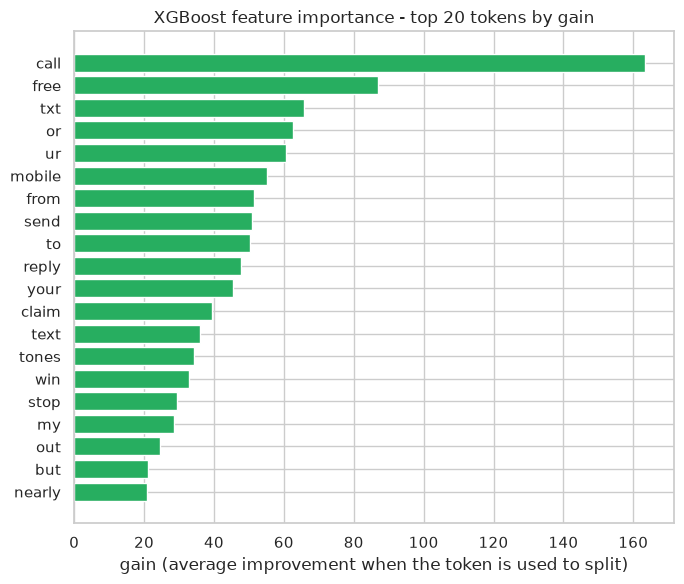

XGBoost used 252 of 3183 available tokens (7.9%) in any split.


,token,gain
44,call,163.481
80,free,86.912
215,txt,65.804
153,or,62.651
219,ur,60.696
133,mobile,55.037
82,from,51.430
174,send,50.949
206,to,50.226
170,reply,47.752


In [8]:
XGB_NAME = "XGBoost"
xgb_pipe = fitted[XGB_NAME]
xgb_vec = xgb_pipe.named_steps["vec"].named_steps["vec"]
xgb_clf = xgb_pipe.named_steps["clf"]
xgb_names = np.asarray(xgb_vec.get_feature_names_out())

booster = xgb_clf.get_booster()
gain = booster.get_score(importance_type="gain")          # keys look like "f123"
gain_idx = {int(k[1:]): v for k, v in gain.items()}
imp = pd.DataFrame({
    "token": [xgb_names[i] for i in gain_idx],
    "gain": list(gain_idx.values()),
}).sort_values("gain", ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp["token"][::-1], imp["gain"][::-1], color="#27ae60")
ax.set_xlabel("gain (average improvement when the token is used to split)")
ax.set_title(f"{XGB_NAME} feature importance - top {TOP_N} tokens by gain")
fig.tight_layout()
fig.savefig(RESULTS / "fig_xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"XGBoost used {len(gain_idx)} of {len(xgb_names)} available tokens "
      f"({100*len(gain_idx)/len(xgb_names):.1f}%) in any split.")
imp.head(10).round(3)

### SHAP

SHAP explains an individual prediction by asking how much each feature moved it away from the
model's average output. `LinearSVC` has no `predict_proba`, so `shap.LinearExplainer` is used
directly against its coefficients and intercept on the **transformed** matrix, with the
vectorizer's feature names supplied manually.

A sample of test messages is used rather than the whole set: the feature matrix is sparse and
densifying all of it would be wasteful, and SHAP summary plots do not become more readable past
a few hundred rows.

Background dataset has 4126 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4126 when initializing the masker.


/tmp/ipykernel_490530/4165403847.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(lin_sv, Z_shap.toarray(), feature_names=feature_names,


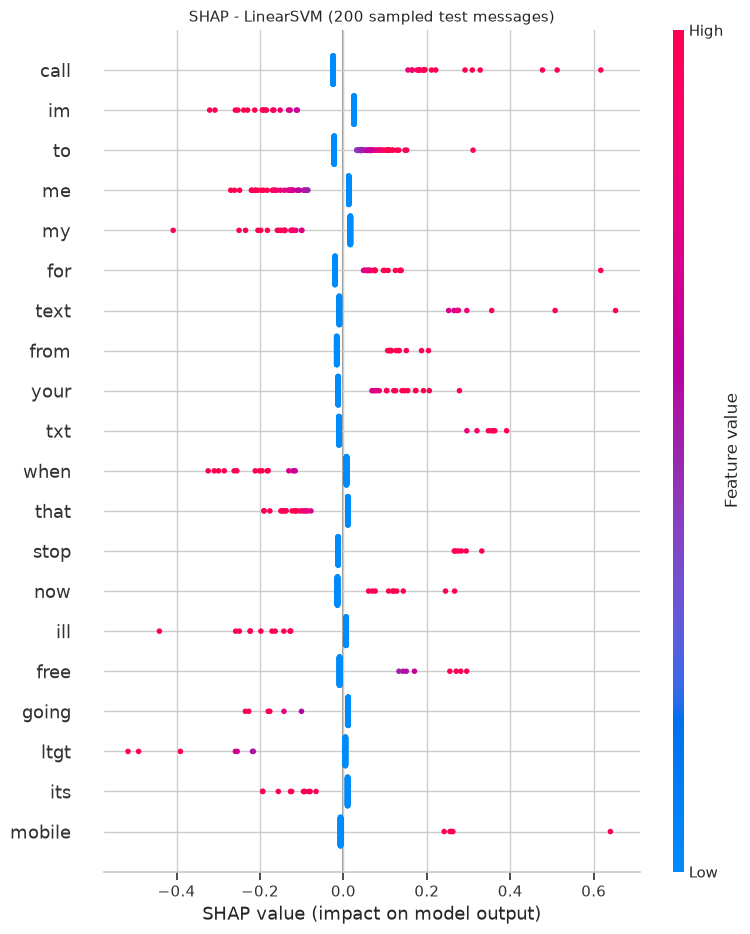

Saved results/fig_shap_linear.png


In [9]:
import shap

SHAP_N = 200
rng = np.random.default_rng(config.RANDOM_SEED)
sample_idx = rng.choice(len(X_test), size=min(SHAP_N, len(X_test)), replace=False)
X_shap = X_test[sample_idx]

# --- linear model ---
lin_pre = lin_pipe.named_steps["vec"]
Z_train = lin_pre.transform(X_train)
Z_shap = lin_pre.transform(X_shap)
lin_expl = shap.LinearExplainer(
    (clf.coef_.reshape(-1), float(np.ravel(clf.intercept_)[0])), Z_train
)
lin_sv = lin_expl.shap_values(Z_shap)

plt.figure()
shap.summary_plot(lin_sv, Z_shap.toarray(), feature_names=feature_names,
                  max_display=20, show=False)
plt.title(f"SHAP - {LINEAR_NAME} ({SHAP_N} sampled test messages)", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS / "fig_shap_linear.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/fig_shap_linear.png")

/tmp/ipykernel_490530/2270103437.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_sv, Zx_shap.toarray(), feature_names=xgb_names,


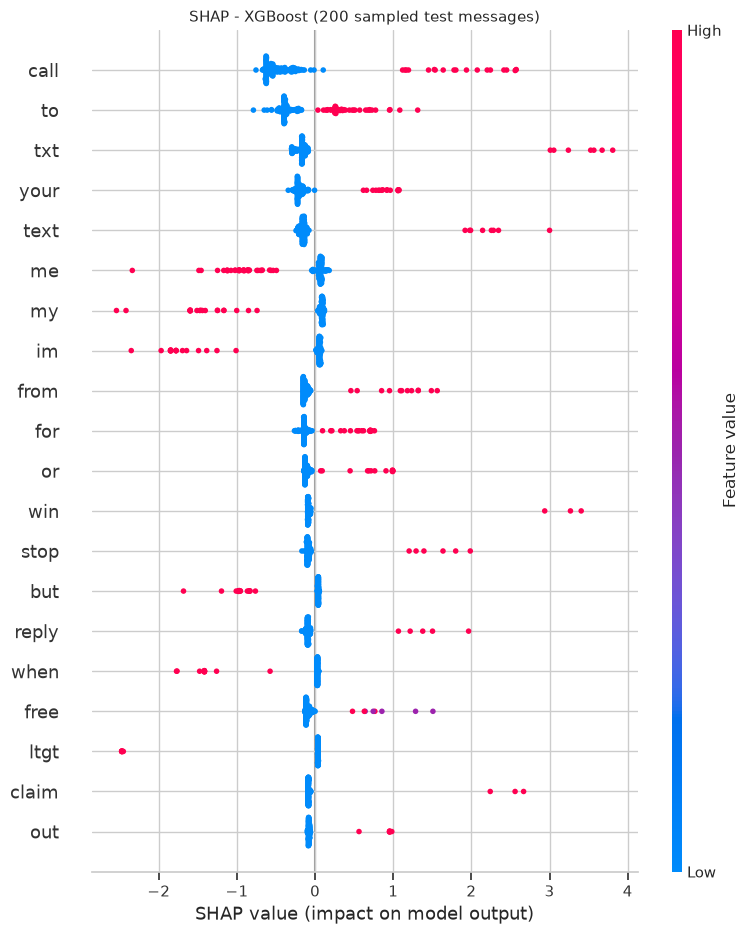

Saved results/fig_shap_xgb.png


In [10]:
# --- XGBoost ---
xgb_pre = xgb_pipe.named_steps["vec"]
Zx_shap = xgb_pre.transform(X_shap)
xgb_expl = shap.TreeExplainer(xgb_clf)
xgb_sv = xgb_expl.shap_values(Zx_shap)

plt.figure()
shap.summary_plot(xgb_sv, Zx_shap.toarray(), feature_names=xgb_names,
                  max_display=20, show=False)
plt.title(f"SHAP - {XGB_NAME} ({SHAP_N} sampled test messages)", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS / "fig_shap_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/fig_shap_xgb.png")

## 4. Efficiency (objective 8)

Training time, per-message prediction latency and stored model size, measured with
`evaluation.time_and_size`. Each configuration is the full pipeline (vectorizer plus
classifier), because in deployment the text still has to be vectorized before it can be
scored - reporting the classifier alone would understate the real cost.

Timings are wall-clock on one CPU machine, so they are a comparison between the models rather
than an absolute benchmark. `OMP_NUM_THREADS=1` is pinned project-wide, which keeps this
comparison fair: no model gets extra threads.

In [11]:
eff_rows = []
for name in MODEL_ORDER:
    pipe, rep, _ = build(name)
    t = time_and_size(pipe, X_train, y_train, X_test, n_repeat=3)
    eff_rows.append({
        "model": name, "representation": rep,
        "fit_time_s": round(t["fit_time_s"], 3),
        "infer_latency_ms": round(t["infer_latency_ms"], 5),
        "model_size_bytes": t["model_size_bytes"],
        "model_size_kb": round(t["model_size_bytes"] / 1024, 1),
        "f1": float(best_rep.loc[name, "f1"]),
        "fpr": float(best_rep.loc[name, "fpr"]),
    })
    print(f"  {name:20s} fit={t['fit_time_s']:6.2f}s  "
          f"latency={t['infer_latency_ms']:.4f} ms/msg  "
          f"size={t['model_size_bytes']/1024:8.1f} KB")

eff = pd.DataFrame(eff_rows)
eff.to_csv(RESULTS / "efficiency.csv", index=False)
print("\nSaved results/efficiency.csv")
eff

  MultinomialNB        fit=  0.11s  latency=0.0267 ms/msg  size=   136.3 KB


  LogisticRegression   fit=  0.20s  latency=0.0446 ms/msg  size=   281.6 KB


  LinearSVM            fit=  0.14s  latency=0.0288 ms/msg  size=    86.7 KB


  XGBoost              fit=  0.45s  latency=0.0324 ms/msg  size=   256.2 KB

Saved results/efficiency.csv


,model,representation,fit_time_s,infer_latency_ms,model_size_bytes,model_size_kb,f1,fpr
0,MultinomialNB,bow,0.114,0.02671,139576,136.3,0.931727,0.005531
1,LogisticRegression,tfidf_bigram,0.204,0.04457,288319,281.6,0.944444,0.005531
2,LinearSVM,tfidf_unigram,0.137,0.02876,88739,86.7,0.948207,0.004425
3,XGBoost,bow,0.446,0.03240,262383,256.2,0.927419,0.005531


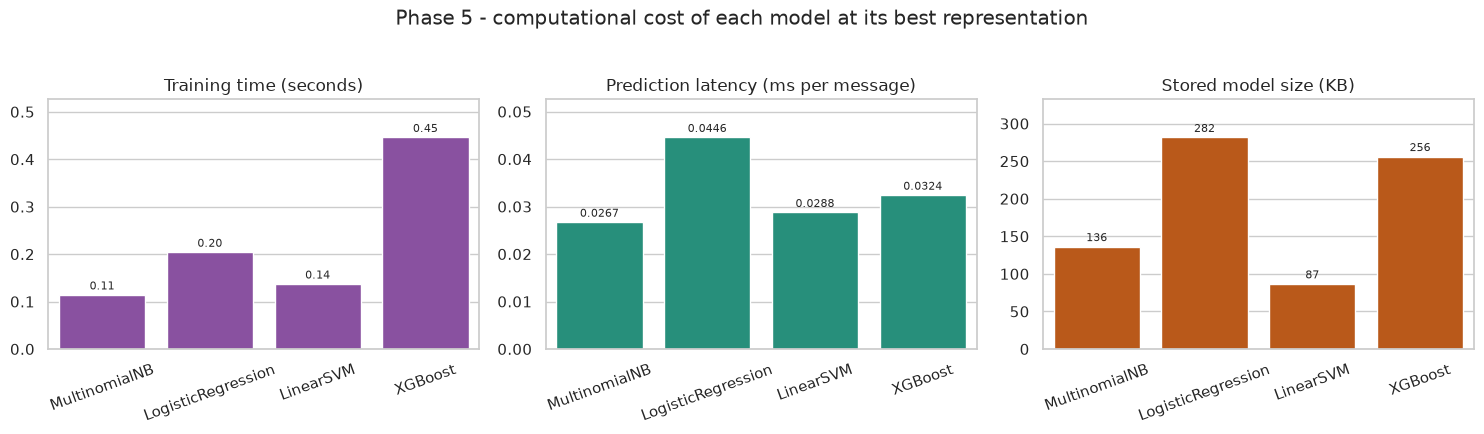

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [
    ("fit_time_s", "Training time (seconds)", "#8e44ad", "%.2f"),
    ("infer_latency_ms", "Prediction latency (ms per message)", "#16a085", "%.4f"),
    ("model_size_kb", "Stored model size (KB)", "#d35400", "%.0f"),
]
for ax, (col, title, colour, fmt) in zip(axes, panels):
    sns.barplot(data=eff, x="model", y=col, ax=ax, color=colour)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
    for cont in ax.containers:
        ax.bar_label(cont, fmt=fmt, fontsize=8, padding=2)
    ax.margins(y=0.18)

fig.suptitle("Phase 5 - computational cost of each model at its best representation", y=1.03)
fig.tight_layout()
fig.savefig(RESULTS / "fig_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Accuracy against cost

The practical question a deployment decision actually turns on: how much accuracy does each
extra second of training and each extra kilobyte buy?

In [13]:
tradeoff = eff[["model", "f1", "fpr", "fit_time_s", "infer_latency_ms", "model_size_kb"]].copy()
tradeoff["f1_per_second"] = (tradeoff["f1"] / tradeoff["fit_time_s"]).round(3)
tradeoff = tradeoff.sort_values("f1", ascending=False)
print(tradeoff.round(4).to_string(index=False))

fastest = eff.loc[eff.fit_time_s.idxmin()]
slowest = eff.loc[eff.fit_time_s.idxmax()]
best_f1 = eff.loc[eff.f1.idxmax()]
smallest = eff.loc[eff.model_size_kb.idxmin()]
print(f"\nFastest to train : {fastest['model']} ({fastest['fit_time_s']:.2f}s)")
print(f"Slowest to train : {slowest['model']} ({slowest['fit_time_s']:.2f}s, "
      f"{slowest['fit_time_s']/fastest['fit_time_s']:.0f}x the fastest)")
print(f"Best F1          : {best_f1['model']} ({best_f1['f1']:.4f})")
print(f"Smallest on disk : {smallest['model']} ({smallest['model_size_kb']:.1f} KB)")
tradeoff

             model     f1    fpr  fit_time_s  infer_latency_ms  model_size_kb  f1_per_second
         LinearSVM 0.9482 0.0044       0.137            0.0288           86.7          6.921
LogisticRegression 0.9444 0.0055       0.204            0.0446          281.6          4.630
     MultinomialNB 0.9317 0.0055       0.114            0.0267          136.3          8.173
           XGBoost 0.9274 0.0055       0.446            0.0324          256.2          2.079

Fastest to train : MultinomialNB (0.11s)
Slowest to train : XGBoost (0.45s, 4x the fastest)
Best F1          : LinearSVM (0.9482)
Smallest on disk : LinearSVM (86.7 KB)


,model,f1,fpr,fit_time_s,infer_latency_ms,model_size_kb,f1_per_second
2,LinearSVM,0.948207,0.004425,0.137,0.02876,86.7,6.921
1,LogisticRegression,0.944444,0.005531,0.204,0.04457,281.6,4.630
0,MultinomialNB,0.931727,0.005531,0.114,0.02671,136.3,8.173
3,XGBoost,0.927419,0.005531,0.446,0.03240,256.2,2.079


## 6. Freeze

Every artifact the report depends on is now written. The check below lists them so a missing
file is caught here rather than halfway through the write-up.

**From this point the results are frozen** - no new experiments, only reproducibility fixes.

In [14]:
EXPECTED = [
    "eda_summary.csv", "master_metrics.csv", "top_models.json", "ablation.csv",
    "hybrid_comparison.csv", "hybrid_stat_coefficients.csv", "significance.csv", "efficiency.csv",
    "split_indices.npz",
    "fig_class_balance.png", "fig_length_by_class.png", "fig_top_tokens.png",
    "fig_master_f1_heatmap.png", "fig_master_fpr_heatmap.png", "fig_roc.png",
    "fig_ablation.png", "fig_hybrid_lift.png",
    "fig_linear_coeffs.png", "fig_xgb_importance.png",
    "fig_shap_linear.png", "fig_shap_xgb.png",
]
missing = [f for f in EXPECTED if not (RESULTS / f).exists()]
for f in EXPECTED:
    mark = "OK     " if (RESULTS / f).exists() else "MISSING"
    print(f"  {mark} {f}")
assert not missing, f"missing artifacts: {missing}"
print(f"\nAll {len(EXPECTED)} artifacts present. Results are FROZEN.")

  OK      eda_summary.csv
  OK      master_metrics.csv
  OK      top_models.json
  OK      ablation.csv
  OK      hybrid_comparison.csv
  OK      hybrid_stat_coefficients.csv
  OK      significance.csv
  OK      efficiency.csv
  OK      split_indices.npz
  OK      fig_class_balance.png
  OK      fig_length_by_class.png
  OK      fig_top_tokens.png
  OK      fig_master_f1_heatmap.png
  OK      fig_master_fpr_heatmap.png
  OK      fig_roc.png
  OK      fig_ablation.png
  OK      fig_hybrid_lift.png
  OK      fig_linear_coeffs.png
  OK      fig_xgb_importance.png
  OK      fig_shap_linear.png
  OK      fig_shap_xgb.png

All 21 artifacts present. Results are FROZEN.
